<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/existing_noise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

⏳ Loading nationwide Census Tract boundaries...
⚠️ Missing/Corrupted states due to incomplete zip download: ['OK', 'OR', 'PA', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA', 'VT', 'WA', 'WI', 'WV', 'WY']
🎨 Generating high-resolution nationwide map...


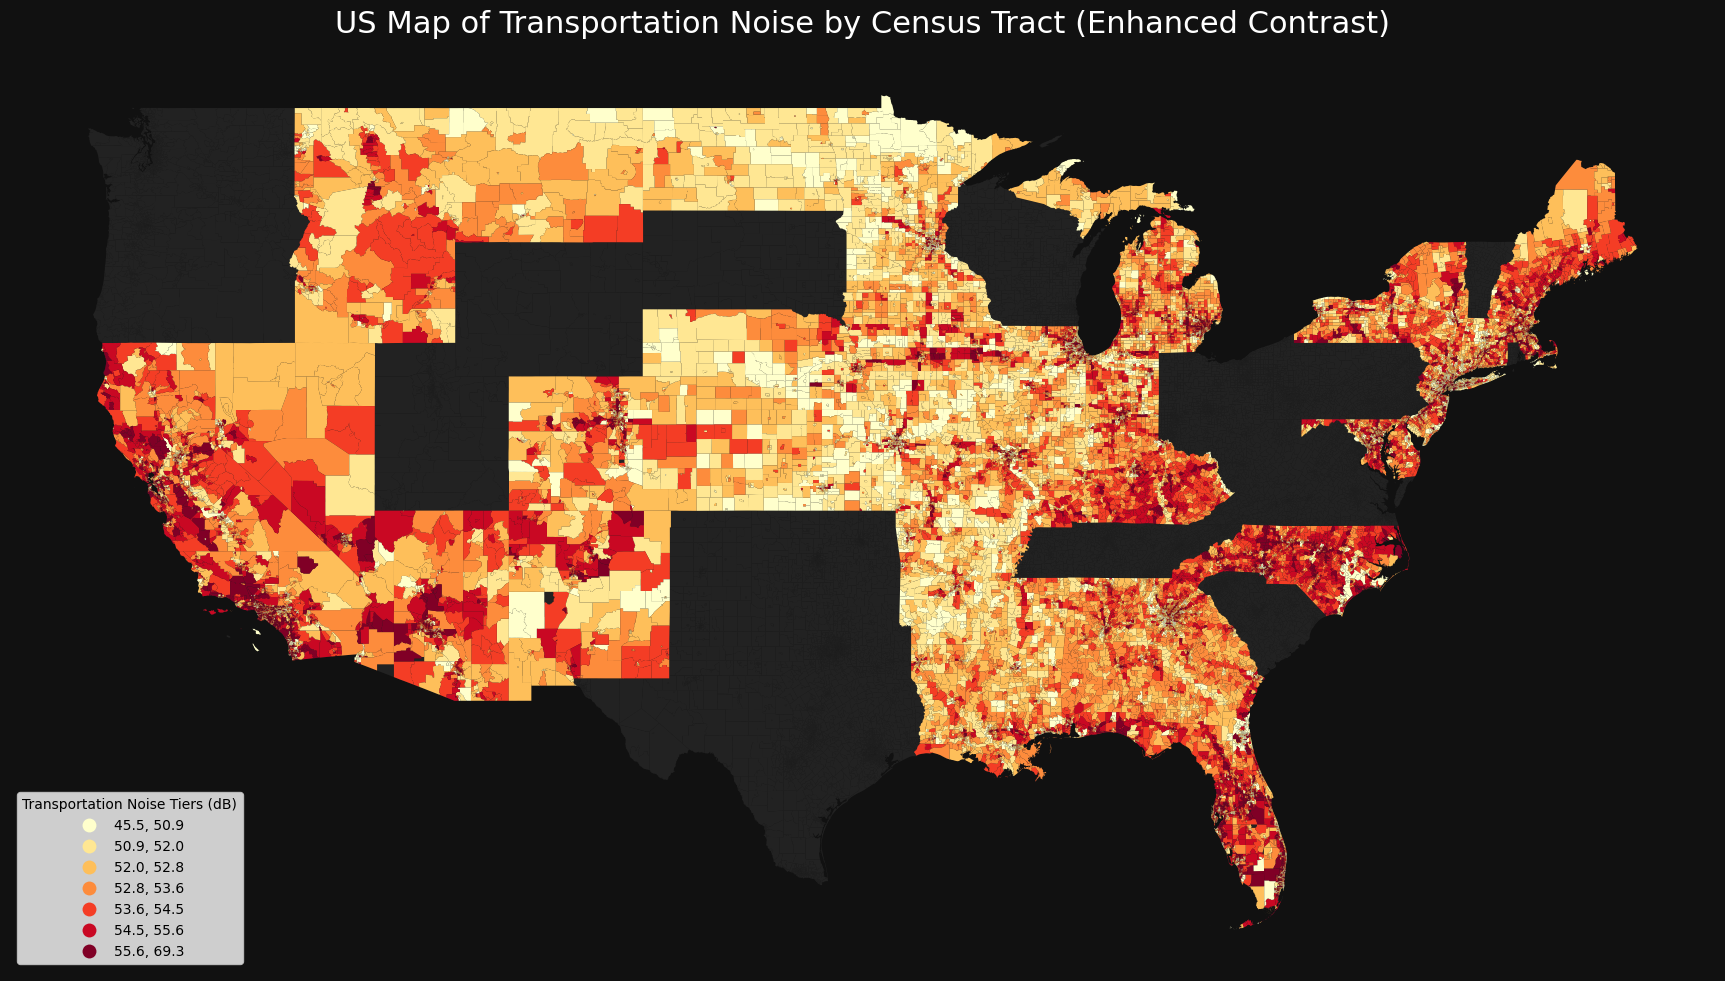

In [17]:

!pip install mapclassify geopandas pandas numpy matplotlib pyogrio rasterio

import os
import glob
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt


FIPS_MAP = {
    'AL': '01', 'AR': '05', 'AZ': '04', 'CA': '06', 'CO': '08', 'CT': '09', 'DE': '10',
    'FL': '12', 'GA': '13', 'IA': '19', 'ID': '16', 'IL': '17', 'IN': '18', 'KS': '20',
    'KY': '21', 'LA': '22', 'MA': '25', 'MD': '24', 'ME': '23', 'MI': '26', 'MN': '27',
    'MO': '29', 'MS': '28', 'MT': '30', 'NC': '37', 'ND': '38', 'NE': '31', 'NH': '33',
    'NJ': '34', 'NM': '35', 'NV': '32', 'NY': '36', 'OH': '39', 'OK': '40', 'OR': '41',
    'PA': '42', 'RI': '44', 'SC': '45', 'SD': '46', 'TN': '47', 'TX': '48', 'UT': '49',
    'VA': '51', 'VT': '50', 'WA': '53', 'WI': '55', 'WV': '54', 'WY': '56', 'DC': '11'
}



url = "https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_tract_500k.zip"
tracts_gdf = gpd.read_file(url, engine="pyogrio")
tracts_gdf['GEOID'] = tracts_gdf['STATEFP'] + tracts_gdf['COUNTYFP'] + tracts_gdf['TRACTCE']
tracts_gdf = tracts_gdf[tracts_gdf['STATEFP'].isin(FIPS_MAP.values())]


raster_dir = "/content/unpacked_data/CONUS_rail_road_and_aviation_noise_2020/State_rasters"
tif_files = glob.glob(os.path.join(raster_dir, "*.tif"))


processed_states = []
all_tract_data = []

for tif_path in tif_files:
    filename = os.path.basename(tif_path)
    state_postal = filename.split('_')[0].upper()
    if state_postal not in FIPS_MAP: continue

    processed_states.append(state_postal)
    state_fips = FIPS_MAP[state_postal]
    state_tracts = tracts_gdf[tracts_gdf['STATEFP'] == state_fips].copy()
    if state_tracts.empty: continue

    try:
        with rasterio.open(tif_path) as src:
            state_tracts_projected = state_tracts.to_crs(src.crs)
            for idx, row in state_tracts_projected.iterrows():
                geom = row['geometry']
                geoid = row['GEOID']
                if geom is None or not geom.is_valid: continue

                left, bottom, right, top = geom.bounds
                window = from_bounds(left, bottom, right, top, transform=src.transform)
                data = src.read(1, window=window, boundless=True, fill_value=src.nodata)
                valid_data = data[(data != src.nodata) & (np.isfinite(data)) & (data > 0)]

                if len(valid_data) > 0:
                    all_tract_data.append({"GEOID": geoid, "mean_noise": float(valid_data.mean())})
    except Exception:
        continue


missing_states = set(FIPS_MAP.keys()) - set(processed_states)



if len(all_tract_data) > 0:
    noise_df = pd.DataFrame(all_tract_data)
    noise_df_grouped = noise_df.groupby("GEOID")["mean_noise"].mean().reset_index()
    merged = tracts_gdf.merge(noise_df_grouped, on="GEOID", how="left")



    fig, ax = plt.subplots(figsize=(22, 12), facecolor='#111111')


    tracts_gdf.plot(ax=ax, color='#222222', edgecolor='#333333', linewidth=0.03)


    merged.dropna(subset=['mean_noise']).plot(
        column="mean_noise",
        cmap="YlOrRd",
        scheme="Quantiles",
        k=7,
        linewidth=0.03,
        edgecolor="none",
        legend=True,
        legend_kwds={
            'title': "Transportation Noise Tiers (dB)",
            'loc': 'lower left',
            'fmt': "{:.1f}"
        },
        ax=ax
    )

    ax.set_title("US Map of Transportation Noise by Census Tract (Enhanced Contrast)", color='white', fontsize=22, pad=15)
    ax.axis("off")


    plt.savefig("enhanced_contrast_noise_map.png", dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor(), edgecolor='none')
    plt.show()
